# Fintech Token paper follow-up

This notebook audits whether the frozen EWMA regime detector is too slow. It uses the supplied Adams–MacKay, Hamilton–Susmel, Rydén–Teräsvirta–Åsbrink, and PELT papers to motivate a small causal family. The decision statistic is paired incremental P&L over simple reversal on the same path.

Alignment: a position at decision index t uses observations through t-1 and earns position[t] * change[t], where change[t] = P[t+1] - P[t]. PELT and state-label shifts are offline diagnostics only.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'research' / 'fintech_token' / 'paper_followup').exists())
followup = root / 'research' / 'fintech_token' / 'paper_followup'
results = followup / 'results'
figures = followup / 'figures'
summary = json.loads((results / 'summary.json').read_text(encoding='utf-8'))
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
print('Root:', root)
print('Candidate builders:', summary['model_counts']['candidate_builder_count'])
print('Combined family:', summary['model_counts']['combined_time_shuffle_family_count'])

Root: D:\Documents\Algojam
Candidate builders: 15
Combined family: 98


## Method and paper mapping

Adams–MacKay supplies the causal run-length recursion and hazard model. The implementation uses Student-t Normal–Inverse-Gamma predictive updates and reads the filtered short-run posterior, because a constant hazard makes the raw next-reset probability equal to the prior hazard. Hamilton–Susmel supplies the variance-regime distinction and the warning that SWARCH does not predict direction. Rydén et al. motivate a volatility-only HMM interpretation but also provide the relevant small-sample and parameter-instability warning. PELT supplies an offline changepoint diagnostic, never a live state.

The tested additions were declared before looking at results: three fast/slow ratios, three asymmetric entry/exit rules, and four raw-change BOCPD-reset durations. The previous 88-model family is included only for family-wise null correction; the earlier EWMA grid was not searched again.

In [2]:
rep = summary['reproduction']
display(pd.DataFrame({
    'quantity': ['prices', 'changes', 'reversal P&L', 'EWMA P&L', 'incremental P&L', 'different days'],
    'value': [rep['prices'], rep['changes'], rep['reversal_pnl'], rep['ewma_pnl'], rep['incremental_pnl'], rep['differing_days']],
}))
display(pd.DataFrame(rep['episodes']))

,quantity,value
0,prices,365.0
1,changes,364.0
2,reversal P&L,75369.0
3,EWMA P&L,157409.0
4,incremental P&L,82040.0
5,different days,73.0


,episode,entry,exit,days,incremental_pnl
0,1,64,65,2,-86.0
1,2,69,78,10,6466.0
2,3,84,89,6,-8168.0
3,4,115,129,15,5050.0
4,5,132,154,23,54754.0
5,6,157,163,7,4992.0
6,7,174,183,10,19032.0


## Phase 1: is the detector late?

The negative state-label shifts are deliberately marked as impossible oracle diagnostics. A negative shift improving P&L would support a latency hypothesis, but the observed negative shifts are all below the causal shift-0 result. The slower lambda settings also create fewer false volatile entries. This points to adequate timing and false-entry/episode-concentration risk, not a demonstrated need for earlier switching.

In [3]:
lambda_timing = pd.read_csv(results / 'lambda_timing.csv')
shifts = pd.read_csv(results / 'state_shifts.csv')
display(lambda_timing[['lambda', 'entries', 'false_runs', 'volatile_days', 'incremental_pnl']])
display(shifts[shifts.shift_days.isin([-10, -5, -2, -1, 0, 1, 2, 5, 10])][['shift_days', 'interpretation', 'incremental_pnl', 'q1_incremental', 'q2_incremental', 'q3_incremental']])

,lambda,entries,false_runs,volatile_days,incremental_pnl
0,0.80,15,8,80,43652.0
1,0.85,13,7,81,51816.0
2,0.90,7,2,73,82040.0
3,0.95,4,2,71,55718.0
4,0.97,1,0,72,60110.0


,shift_days,interpretation,incremental_pnl,q1_incremental,q2_incremental,q3_incremental
0,-10,oracle_early_impossible,21540.0,-14298.0,35838.0,0.0
5,-5,oracle_early_impossible,43772.0,-1714.0,45486.0,0.0
8,-2,oracle_early_impossible,44526.0,-19004.0,63530.0,0.0
9,-1,oracle_early_impossible,68174.0,-8588.0,72770.0,3992.0
10,0,causal_benchmark,82040.0,-1788.0,82252.0,1576.0
11,1,causal_delay_diagnostic,80846.0,-4272.0,81576.0,3542.0
12,2,causal_delay_diagnostic,57682.0,-6958.0,62230.0,2410.0
15,5,causal_delay_diagnostic,15391.0,-2777.0,16672.0,1496.0
20,10,causal_delay_diagnostic,-1227.0,-24205.0,32384.0,-9406.0


In [4]:
event_grouped = pd.read_csv(results / 'event_study_grouped.csv')
display(event_grouped[event_grouped.relative_day.between(-2, 3)][['event_type', 'relative_day', 'events', 'mean_continuation', 'mean_incremental_pnl']])
display(pd.read_csv(results / 'pelt_boundaries.csv').query('penalty_multiplier == 2.0'))

,event_type,relative_day,events,mean_continuation,mean_incremental_pnl
8,entry,-2,7,-11.848571,0.000000
9,entry,-1,7,-0.818571,0.000000
10,entry,0,7,5.115714,-163.714286
11,entry,1,7,6.542857,1023.142857
12,entry,2,7,2.422857,1374.571429
13,entry,3,7,12.102857,822.857143
29,exit,-2,7,-1.944286,1614.857143
30,exit,-1,7,-0.778571,-388.857143
31,exit,0,7,-11.818571,0.000000
32,exit,1,7,-6.438571,0.000000


,cost,penalty_multiplier,penalty,boundary,nearest_ewma_gap_days
2,variance,2.0,11.794308,59.0,5.0
3,variance,2.0,11.794308,207.0,24.0
7,absolute_mean,2.0,11.794308,NaN,NaN
24,ar1,2.0,11.794308,63.0,1.0
25,ar1,2.0,11.794308,83.0,1.0
26,ar1,2.0,11.794308,112.0,3.0
27,ar1,2.0,11.794308,132.0,0.0
28,ar1,2.0,11.794308,156.0,1.0
29,ar1,2.0,11.794308,182.0,1.0
30,ar1,2.0,11.794308,203.0,20.0


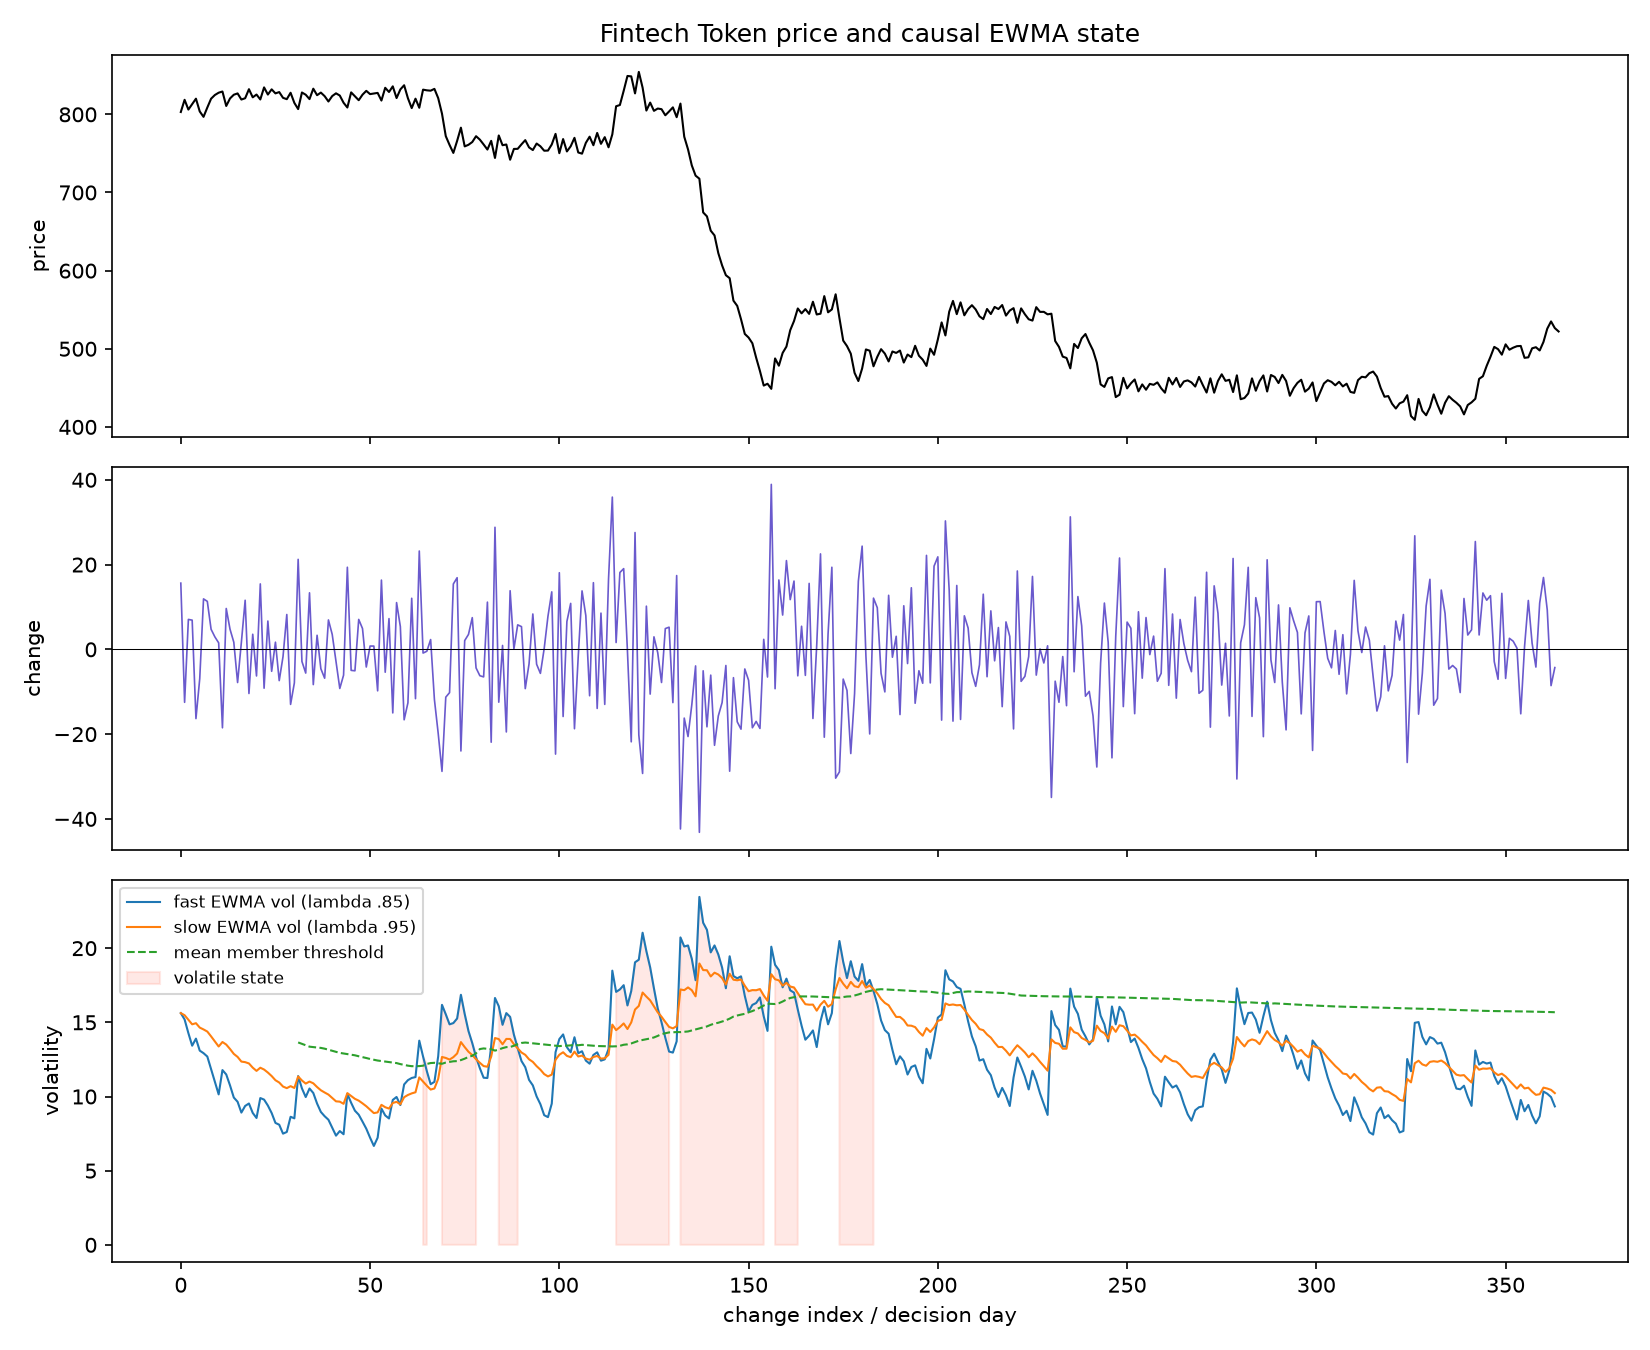

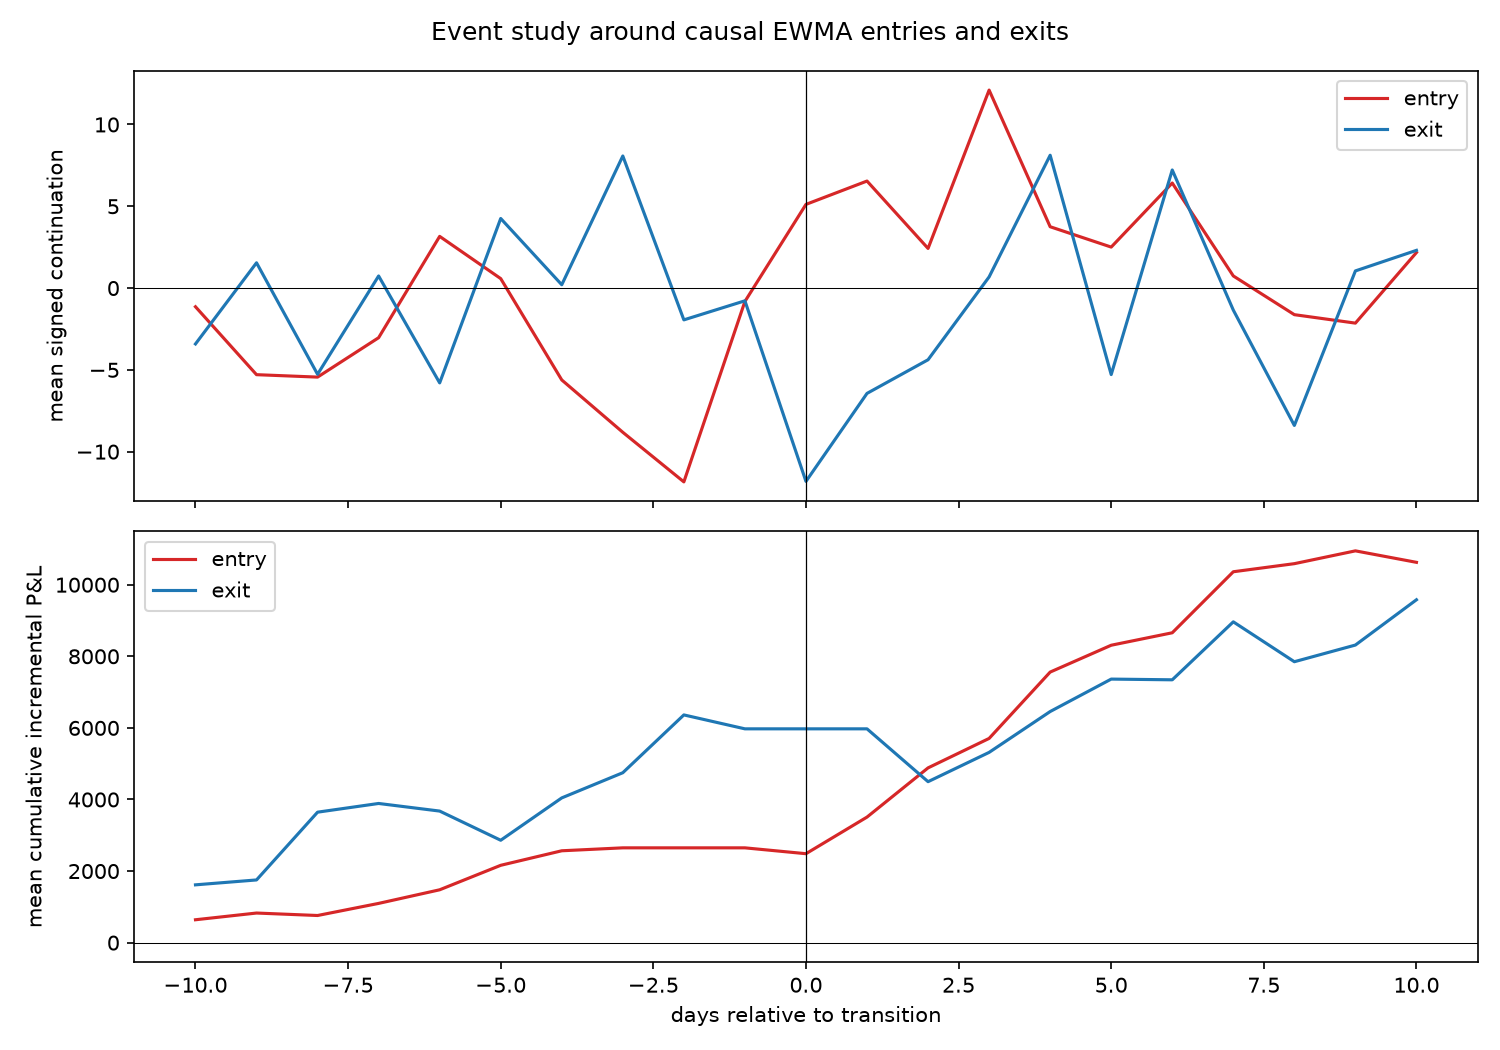

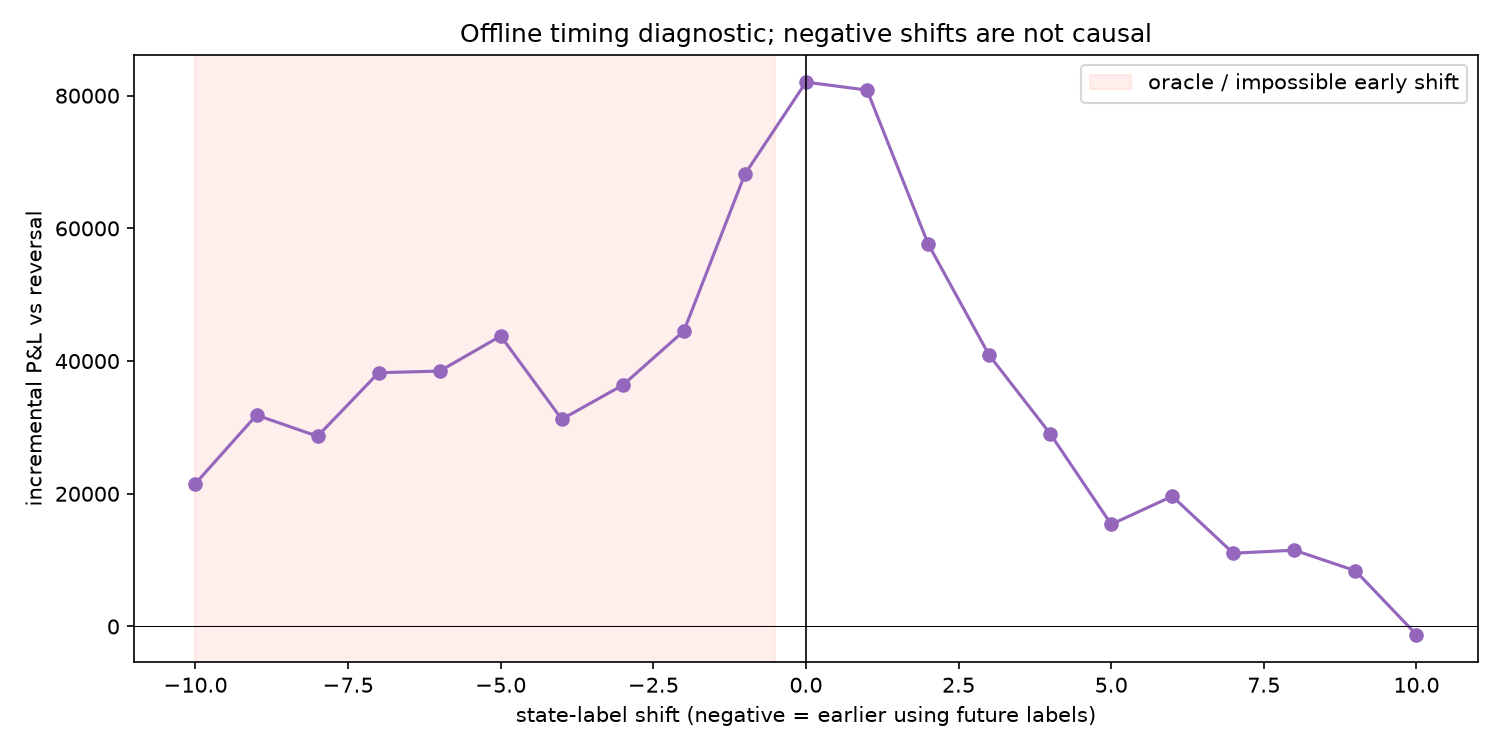

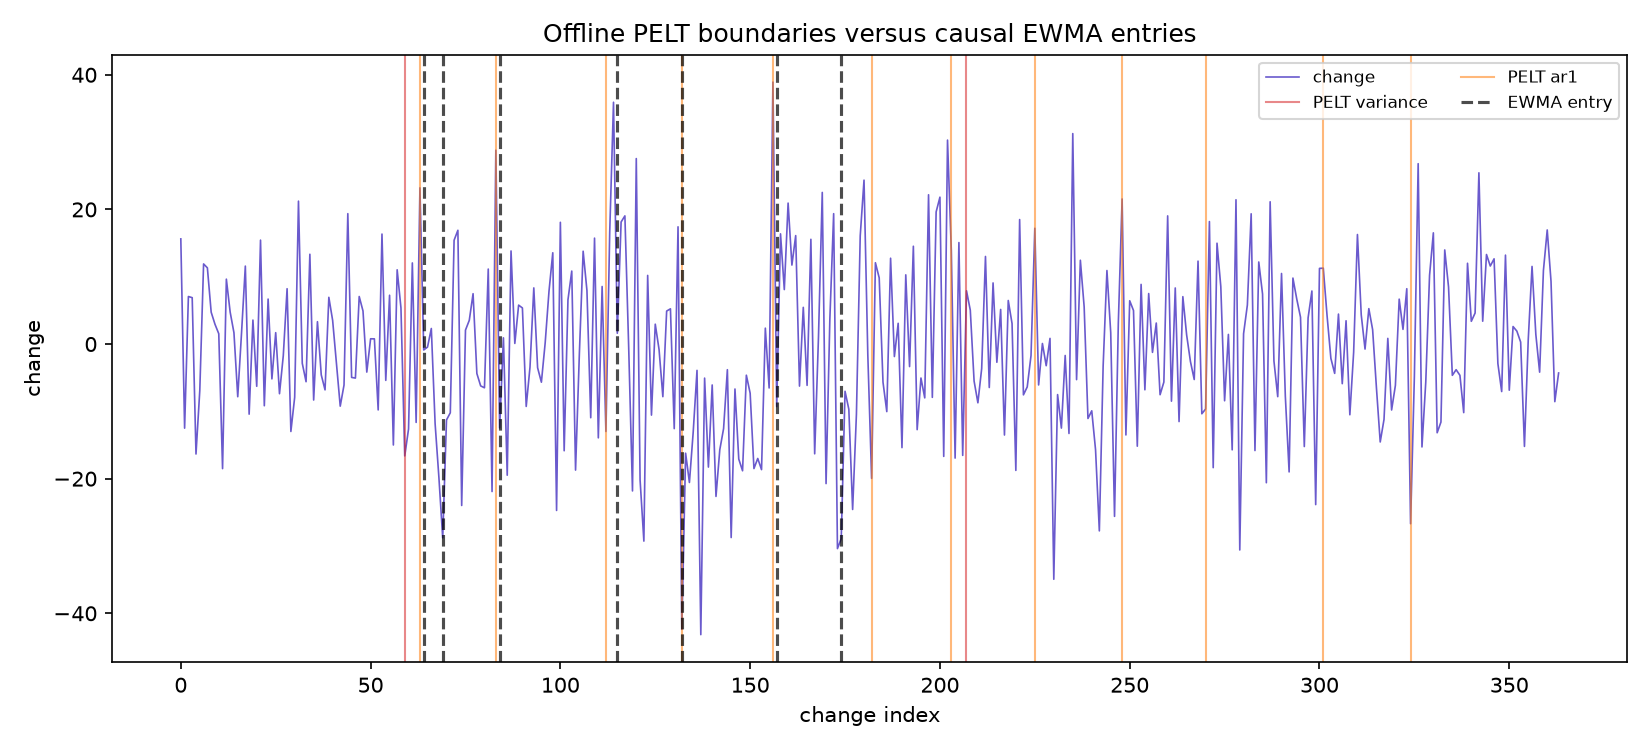

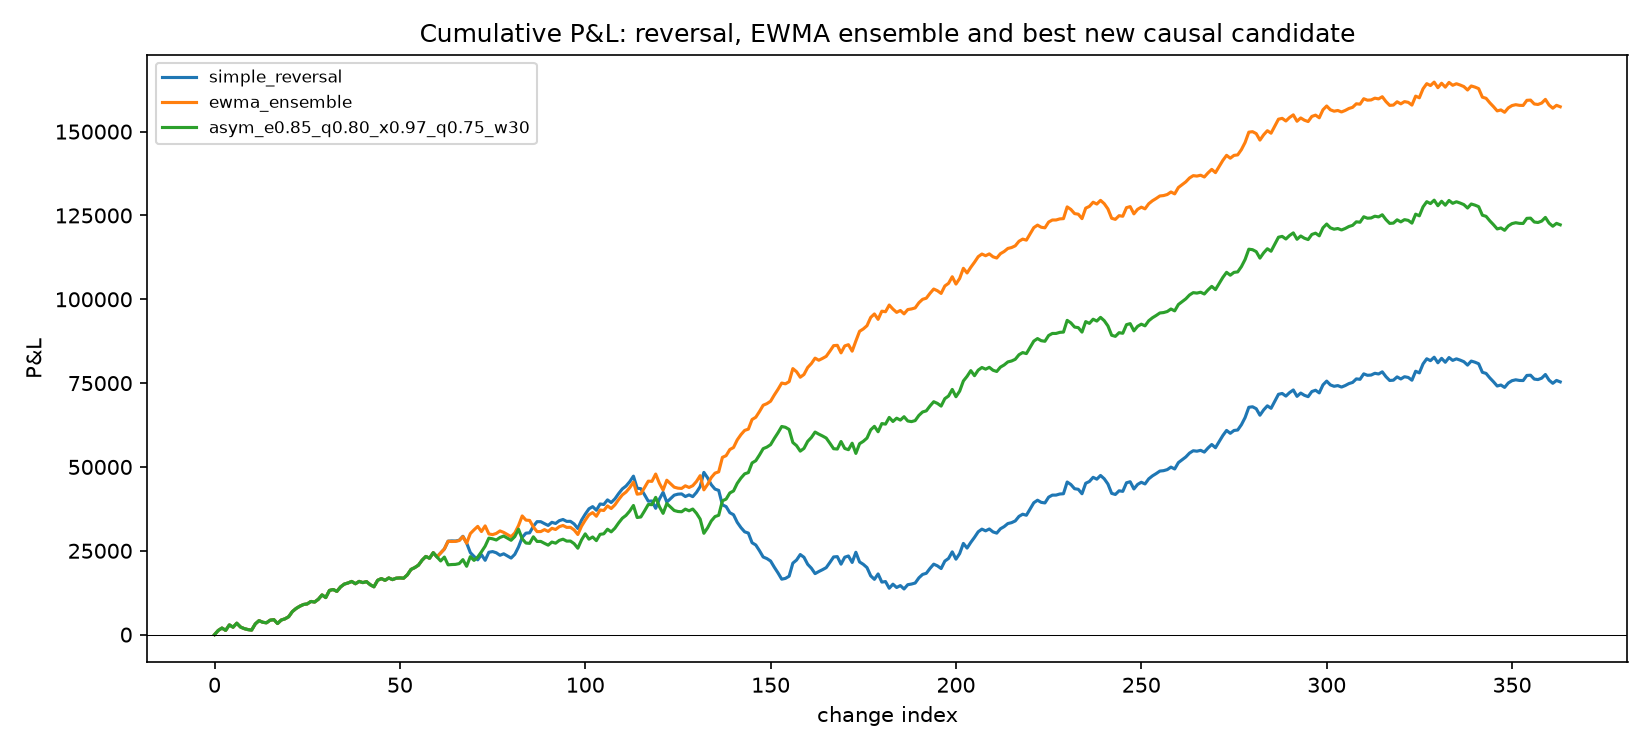

In [5]:
for filename in ['timing_audit.png', 'event_study.png', 'state_shift_audit.png', 'pelt_boundaries.png', 'candidate_pnl.png']:
    display(Image(filename=str(figures / filename), width=850))

## BOCPD and causal challenger results

The raw one-step change probability stays at the declared hazard under a constant hazard. Data-dependent evidence appears in short-run posterior mass and posterior mean run length. Raw changes give only a few short-run triggers for expected durations 40–90; squared and residual observations generate more alarms, which is why they remain diagnostics rather than frozen traded configurations.

In [6]:
bocpd = pd.read_csv(results / 'bocpd_diagnostics.csv')
display(bocpd[['observation', 'expected_duration', 'hazard', 'max_raw_reset_probability', 'short_run_q95', 'short_run_trigger_count_at_020', 'minimum_run_index']])

candidates = pd.read_csv(results / 'candidate_results.csv')
columns = ['model', 'pnl', 'incremental_pnl', 'max_drawdown', 'active_days', 'turnover_events', 'max_capital', 'pnl_per_max_capital']
display(candidates[columns])

,observation,expected_duration,hazard,max_raw_reset_probability,short_run_q95,short_run_trigger_count_at_020,minimum_run_index
0,raw,20,0.050000,0.050000,0.211109,21,156
1,raw,40,0.025000,0.025000,0.107971,3,162
2,raw,60,0.016667,0.016667,0.077448,3,162
3,raw,90,0.011111,0.011111,0.053834,2,162
4,absolute,20,0.050000,0.050000,0.302062,61,80
5,absolute,40,0.025000,0.025000,0.165633,8,69
6,absolute,60,0.016667,0.016667,0.111826,2,69
7,absolute,90,0.011111,0.011111,0.079180,1,219
8,squared,20,0.050000,0.050000,0.532971,101,324
9,squared,40,0.025000,0.025000,0.344150,36,324


,model,pnl,incremental_pnl,max_drawdown,active_days,turnover_events,max_capital,pnl_per_max_capital
0,ewma_ensemble,157409.0,82040.0,-8996.0,363,206,85434.0,1.842463
1,asym_e0.85_q0.80_x0.97_q0.75_w30,122211.0,46842.0,-10718.0,363,202,85434.0,1.430473
2,asym_e0.80_q0.85_x0.95_q0.75_w30,120503.0,45134.0,-10718.0,363,200,85434.0,1.410481
3,asym_e0.80_q0.80_x0.90_q0.70_w30,112277.0,36908.0,-12789.0,363,204,85434.0,1.314196
4,bocpd_raw_d90_r0.20,91671.0,16302.0,-25976.0,363,214,85434.0,1.073004
5,bocpd_raw_d40_r0.20,81759.0,6390.0,-36624.0,363,212,85434.0,0.956984
6,bocpd_raw_d60_r0.20,81759.0,6390.0,-36624.0,363,212,85434.0,0.956984
7,simple_reversal,75369.0,0.0,-34766.0,363,210,85434.0,0.882190
8,bocpd_raw_d20_r0.20,69821.0,-5548.0,-33188.0,363,218,85434.0,0.817251
9,ratio_f0.85_s0.97_q0.85_w30,61449.0,-13920.0,-23898.0,363,200,85434.0,0.719257


## Paired robustness

Every row below compares a candidate and simple reversal on the same resampled path. The moving-block table uses 1,000 repetitions for core candidates and 250 for BOCPD candidates; the repetition count is visible in the table. Confidence intervals crossing zero are expected for a 364-change path and are not converted into claims of certainty.

In [7]:
mbb = pd.read_csv(results / 'paired_moving_block_bootstrap.csv')
selected = ['ewma_ensemble', 'ratio_f0.85_s0.97_q0.85_w30', 'asym_e0.85_q0.80_x0.97_q0.75_w30', 'bocpd_raw_d90_r0.20']
display(mbb[mbb.model.isin(selected)][['model', 'block_length_or_mean', 'reps', 'mean_incremental_pnl', 'ci025_incremental_pnl', 'ci975_incremental_pnl', 'prob_increment_gt_zero']])

,model,block_length_or_mean,reps,mean_incremental_pnl,ci025_incremental_pnl,ci975_incremental_pnl,prob_increment_gt_zero
0,ewma_ensemble,5,1000,-3702.236,-57954.30,47369.20,0.441
3,ratio_f0.85_s0.97_q0.85_w30,5,1000,1107.072,-44938.55,40004.35,0.577
6,asym_e0.85_q0.80_x0.97_q0.75_w30,5,1000,-20498.020,-97137.80,41806.95,0.302
10,bocpd_raw_d90_r0.20,5,250,-2213.736,-56829.60,41489.75,0.516
11,ewma_ensemble,10,1000,11507.172,-55328.80,74948.25,0.646
14,ratio_f0.85_s0.97_q0.85_w30,10,1000,9804.932,-36336.55,60228.80,0.690
17,asym_e0.85_q0.80_x0.97_q0.75_w30,10,1000,-7792.396,-96810.95,63225.60,0.451
21,bocpd_raw_d90_r0.20,10,250,9959.368,-38802.70,66061.25,0.620
22,ewma_ensemble,20,1000,28154.330,-49426.25,116480.55,0.723
25,ratio_f0.85_s0.97_q0.85_w30,20,1000,13990.310,-35630.95,74092.45,0.714


In [8]:
stationary = pd.read_csv(results / 'paired_stationary_bootstrap.csv')
display(stationary[stationary.model.isin(selected)][['model', 'block_length_or_mean', 'reps', 'mean_incremental_pnl', 'ci025_incremental_pnl', 'ci975_incremental_pnl', 'prob_increment_gt_zero']])
display(pd.read_csv(results / 'q2_exclusions.csv'))
display(pd.read_csv(results / 'episode_exclusions.csv').query('model == "ewma_ensemble"'))

,model,block_length_or_mean,reps,mean_incremental_pnl,ci025_incremental_pnl,ci975_incremental_pnl,prob_increment_gt_zero
0,ewma_ensemble,10,300,22239.813333,-49524.30,108309.85,0.716667
3,ratio_f0.85_s0.97_q0.85_w30,10,300,10765.713333,-48958.15,67454.55,0.710000
6,asym_e0.85_q0.80_x0.97_q0.75_w30,10,300,-3346.513333,-108003.60,99105.40,0.490000
10,bocpd_raw_d90_r0.20,10,150,12875.400000,-41711.65,68788.90,0.646667
11,ewma_ensemble,20,300,31180.313333,-50040.45,122776.40,0.716667
14,ratio_f0.85_s0.97_q0.85_w30,20,300,9510.626667,-43475.00,68187.00,0.640000
17,asym_e0.85_q0.80_x0.97_q0.75_w30,20,300,440.346667,-103243.45,114306.40,0.496667
21,bocpd_raw_d90_r0.20,20,150,19701.560000,-49453.20,96933.20,0.666667


,model,full_incremental,incremental_excluding_q2,full_pnl,pnl_excluding_q2
0,ewma_ensemble,82040.0,-212.0,157409.0,91893.0
1,ratio_f0.80_s0.95_q0.80_w30,-30616.0,-43174.0,44753.0,48931.0
2,ratio_f0.80_s0.97_q0.80_w30,-15506.0,-32784.0,59863.0,59321.0
3,ratio_f0.85_s0.97_q0.85_w30,-13920.0,-33354.0,61449.0,58751.0
4,asym_e0.80_q0.80_x0.90_q0.70_w30,36908.0,-15550.0,112277.0,76555.0
5,asym_e0.80_q0.85_x0.95_q0.75_w30,45134.0,-6074.0,120503.0,86031.0
6,asym_e0.85_q0.80_x0.97_q0.75_w30,46842.0,-5986.0,122211.0,86119.0
7,bocpd_raw_d20_r0.20,-5548.0,6924.0,69821.0,99029.0
8,bocpd_raw_d40_r0.20,6390.0,7928.0,81759.0,100033.0
9,bocpd_raw_d60_r0.20,6390.0,7928.0,81759.0,100033.0


,model,removed_episode,entry,exit,full_incremental,incremental_excluding_episode
0,ewma_ensemble,1,64,65,82040.0,82126.0
11,ewma_ensemble,2,69,78,82040.0,75574.0
22,ewma_ensemble,3,84,89,82040.0,90208.0
33,ewma_ensemble,4,115,129,82040.0,76990.0
44,ewma_ensemble,5,132,154,82040.0,27286.0
55,ewma_ensemble,6,157,163,82040.0,77048.0
66,ewma_ensemble,7,174,183,82040.0,63008.0


In [9]:
starts = pd.read_csv(results / 'chronological_starts.csv')
resets = pd.read_csv(results / 'independent_resets.csv')
delayed = pd.read_csv(results / 'delayed_execution.csv')
future = pd.read_csv(results / 'future_perturbation.csv')
display(starts[starts.model.isin(selected)][['model', 'start', 'incremental_pnl']])
display(delayed[delayed.model.isin(selected)][['model', 'original_incremental_pnl', 'delayed_incremental_pnl']])
print('Future-prefix failures:', int((future.prefix_equal == 0).sum()))
print('Family time-shuffle:', json.loads((results / 'family_time_shuffle.json').read_text())['family_wise_p_value'])
print('Family circular-shift:', json.loads((results / 'family_circular_shift.json').read_text())['family_wise_p_value'])

,model,start,incremental_pnl
0,ewma_ensemble,0,82040.0
1,ewma_ensemble,60,59350.0
2,ewma_ensemble,90,32500.0
3,ewma_ensemble,120,0.0
4,ewma_ensemble,180,0.0
5,ewma_ensemble,240,-7646.0
18,ratio_f0.85_s0.97_q0.85_w30,0,-13920.0
19,ratio_f0.85_s0.97_q0.85_w30,60,2154.0
20,ratio_f0.85_s0.97_q0.85_w30,90,0.0
21,ratio_f0.85_s0.97_q0.85_w30,120,-20948.0


,model,original_incremental_pnl,delayed_incremental_pnl
0,ewma_ensemble,82040.0,53852.0
3,ratio_f0.85_s0.97_q0.85_w30,-13920.0,11056.0
6,asym_e0.85_q0.80_x0.97_q0.75_w30,46842.0,56634.0
10,bocpd_raw_d90_r0.20,16302.0,25160.0


Future-prefix failures: 0
Family time-shuffle: 0.009900990099009901
Family circular-shift: 0.19801980198019803


## Model selection

| Model | Causal? | Full P&L / incremental | Main robustness read | Decision |
|---|---|---:|---|---|
| Simple reversal | Yes | $75,369 / $0 | Low-complexity benchmark | Fallback |
| EWMA diagonal ensemble | Yes | $157,409 / +$82,040 | Positive medium/long-block paired results; delayed +$53,852; Q2-excluded -$212 | **Retain** |
| Fast/slow ratio | Yes | Best $61,449 / -$13,920 | All tested full paths lose to reversal | Reject |
| Asymmetric entry/exit | Yes | Best $122,211 / +$46,842 | Q2-dependent; short-block MBB negative | Reject |
| BOCPD-reset EWMA | Yes | Best $91,671 / +$16,302 | Duration-sensitive; CIs include zero; lower reps | Reject |
| HMM/SWARCH | Not traded | — | Too many estimated state/variance parameters for the sample | Defer |
| PELT | No | — | Offline diagnostic only | Never trade |

The new family does not satisfy the replacement standard: no new causal detector improves across multiple independent episodes while preserving drawdown, parameter stability, and delayed execution. The final recommendation is therefore to retain the frozen EWMA ensemble.

## Final conclusion and Round 2 startup

Use the existing ensemble with parameters (0.85, .75, 30), (0.90, .80, 30), and (0.95, .85, 30), full ±100 sizing, simple reversal during warm-up, and position 0 when there is no prior change or the latest change is zero/non-finite. Do not adapt parameters after seeing Round 2. Log the state and thresholds so a new sustained episode can be evaluated against simple reversal before any policy change.

The following sketch is copy-ready for review only; it does not modify production files.

In [10]:
def fintech_position(price_history):
    prices = np.asarray(price_history, dtype=float)
    if len(prices) < 2 or not np.all(np.isfinite(prices[-2:])):
        return 0
    changes = np.diff(prices)
    latest = float(changes[-1])
    if latest == 0.0:
        return 0
    if len(changes) <= 30:
        return int(-100 * np.sign(latest))
    votes = []
    for lam, percentile in ((0.85, 0.75), (0.90, 0.80), (0.95, 0.85)):
        variance = float(changes[0] ** 2)
        vols = [np.sqrt(max(variance, 0.0))]
        for move in changes[1:]:
            variance = lam * variance + (1.0 - lam) * float(move ** 2)
            vols.append(np.sqrt(max(variance, 0.0)))
        votes.append(1 if vols[-1] >= np.quantile(np.asarray(vols[:-1]), percentile) else -1)
    state = 1 if sum(votes) > 0 else -1
    return int(100 * state * np.sign(latest))